In [1]:
import pandas as pd
import numpy as np

In [2]:
ruta = '/content/TelecomX_Data.json'

In [3]:
data = pd.read_json(ruta)

In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   customerID  7267 non-null   object
 1   Churn       7267 non-null   object
 2   customer    7267 non-null   object
 3   phone       7267 non-null   object
 4   internet    7267 non-null   object
 5   account     7267 non-null   object
dtypes: object(6)
memory usage: 340.8+ KB


In [5]:
data.dtypes

,0
customerID,object
Churn,object
customer,object
phone,object
internet,object
account,object


In [6]:
data['customerID'].unique()

array(['0002-ORFBO', '0003-MKNFE', '0004-TLHLJ', ..., '9992-UJOEL',
       '9993-LHIEB', '9995-HOTOH'], dtype=object)

In [7]:
data.customerID.unique()

array(['0002-ORFBO', '0003-MKNFE', '0004-TLHLJ', ..., '9992-UJOEL',
       '9993-LHIEB', '9995-HOTOH'], dtype=object)

In [8]:
data['customerID'].apply(pd.Series)

,0
0,0002-ORFBO
1,0003-MKNFE
2,0004-TLHLJ
3,0011-IGKFF
4,0013-EXCHZ
...,...
7262,9987-LUTYD
7263,9992-RRAMN
7264,9992-UJOEL
7265,9993-LHIEB


###📌 Extracción

In [9]:
data['account'][0]

{'Contract': 'One year',
 'PaperlessBilling': 'Yes',
 'PaymentMethod': 'Mailed check',
 'Charges': {'Monthly': 65.6, 'Total': '593.3'}}

In [10]:
# Ejemplo de cómo se extraería si fuera un diccionario anidado
data['Facturacion_Mensual'] = data['account'].str['Charges'].str['Monthly']

# Asegurarnos de que Pandas lo lea como número (float)
data['Facturacion_Mensual'] = data['Facturacion_Mensual'].astype(float)

In [11]:
data.dtypes

,0
customerID,object
Churn,object
customer,object
phone,object
internet,object
account,object
Facturacion_Mensual,float64


In [12]:
data.head()

,customerID,Churn,customer,phone,internet,account,Facturacion_Mensual
0,0002-ORFBO,No,"{'gender': 'Female', 'SeniorCitizen': 0, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'One year', 'PaperlessBilling': '...",65.6
1,0003-MKNFE,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'Yes'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'Month-to-month', 'PaperlessBilli...",59.9
2,0004-TLHLJ,Yes,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli...",73.9
3,0011-IGKFF,Yes,"{'gender': 'Male', 'SeniorCitizen': 1, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli...",98.0
4,0013-EXCHZ,Yes,"{'gender': 'Female', 'SeniorCitizen': 1, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli...",83.9


In [13]:
# 1. Extraemos los datos de cada columna con diccionarios
df_customer = pd.json_normalize(data['customer'])
df_phone = pd.json_normalize(data['phone'])
df_internet = pd.json_normalize(data['internet'])
df_account = pd.json_normalize(data['account'])

In [14]:
# 2. Unimos todo junto con las columnas que ya estaban bien (customerID y Churn)
data_limpia = pd.concat([data[['customerID', 'Churn']], df_customer, df_phone, df_internet, df_account], axis=1)

In [15]:
data_limpia.head()

,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,...,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges.Monthly,Charges.Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.4


In [16]:
# Convertimos Charges.Total a numérico (float).
data_limpia['Charges.Total'] = pd.to_numeric(data_limpia['Charges.Total'], errors='coerce')

# Verificamos los cambios
data_limpia[['tenure', 'Charges.Monthly', 'Charges.Total']].dtypes

,0
tenure,int64
Charges.Monthly,float64
Charges.Total,float64


In [17]:
data_limpia.dtypes

,0
customerID,object
Churn,object
gender,object
SeniorCitizen,int64
Partner,object
Dependents,object
tenure,int64
PhoneService,object
MultipleLines,object
InternetService,object


In [18]:
# Esto mostrará una lista de tus columnas y cuántos valores nulos tiene cada una
data_limpia.isnull().sum()

,0
customerID,0
Churn,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0


In [19]:
data_limpia['Charges.Total'] = data_limpia['Charges.Total'].ffill()

In [20]:
data_limpia['Cuentas_Diarias'] = round(data_limpia['Charges.Monthly'] / 30, 2)

In [21]:
data_limpia[['customerID', 'Charges.Monthly', 'Cuentas_Diarias']].head()

,customerID,Charges.Monthly,Cuentas_Diarias
0,0002-ORFBO,65.6,2.19
1,0003-MKNFE,59.9,2.00
2,0004-TLHLJ,73.9,2.46
3,0011-IGKFF,98.0,3.27
4,0013-EXCHZ,83.9,2.80


In [22]:
# Muestra los valores únicos de todas las columnas de texto sin usar ciclos
data_limpia.select_dtypes(include=['object']).agg('unique')

array(['', '0002-ORFBO', '0003-MKNFE', ..., 'One year', 'Two year', 'Yes'],
      dtype=object)

In [23]:
# Muestra los valores únicos separados por columna, manteniendo un código limpio y sin ciclos
data_limpia.select_dtypes(include=['object']).apply(lambda x: x.unique())

,0
customerID,"[0002-ORFBO, 0003-MKNFE, 0004-TLHLJ, 0011-IGKF..."
Churn,"[No, Yes, ]"
gender,"[Female, Male]"
Partner,"[Yes, No]"
Dependents,"[Yes, No]"
PhoneService,"[Yes, No]"
MultipleLines,"[No, Yes, No phone service]"
InternetService,"[DSL, Fiber optic, No]"
OnlineSecurity,"[No, Yes, No internet service]"
OnlineBackup,"[Yes, No, No internet service]"


#🔧 Transformación

In [24]:
# Contamos exactamente cuántas veces aparece cada categoría, incluyendo los espacios
data_limpia['Churn'].value_counts()

,count
Churn,
No,5174
Yes,1869
,224


In [25]:
# 1. ELIMINAR INCONSISTENCIAS: Quitamos los espacios y filtramos los vacíos en Churn
data_limpia['Churn'] = data_limpia['Churn'].str.strip()
data_limpia = data_limpia[data_limpia['Churn'] != '']

In [26]:
# 2. BINARIZAR: Transformamos Yes/No a 1/0 en todo el DataFrame
data_limpia = data_limpia.replace({'Yes': 1, 'No': 0})

/tmp/ipykernel_532/3414687454.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data_limpia = data_limpia.replace({'Yes': 1, 'No': 0})


In [27]:
# Binarizar también el género (Femenino = 1, Masculino = 0)
data_limpia['gender'] = data_limpia['gender'].replace({'Female': 1, 'Male': 0})


/tmp/ipykernel_532/101660988.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data_limpia['gender'] = data_limpia['gender'].replace({'Female': 1, 'Male': 0})


In [28]:
# 3. TRADUCIR: Renombramos las columnas para mayor claridad
traduccion_columnas = {
    'customerID': 'ID_Cliente',
    'Churn': 'Fuga',
    'gender': 'Genero',
    'tenure': 'Meses_Antiguedad',
    'PhoneService': 'Servicio_Telefonico',
    'MultipleLines': 'Multiples_Lineas',
    'InternetService': 'Servicio_Internet',
    'Contract': 'Contrato',
    'PaperlessBilling': 'Factura_Digital',
    'PaymentMethod': 'Metodo_Pago',
    'Charges.Monthly': 'Cargo_Mensual',
    'Charges.Total': 'Cargo_Total'
}

In [29]:
data_limpia = data_limpia.rename(columns=traduccion_columnas)

In [30]:
data_limpia.head()

,ID_Cliente,Fuga,Genero,SeniorCitizen,Partner,Dependents,Meses_Antiguedad,Servicio_Telefonico,Multiples_Lineas,Servicio_Internet,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contrato,Factura_Digital,Metodo_Pago,Cargo_Mensual,Cargo_Total,Cuentas_Diarias
0,0002-ORFBO,0,1,0,1,1,9,1,0,DSL,...,0,1,1,0,One year,1,Mailed check,65.6,593.30,2.19
1,0003-MKNFE,0,0,0,0,0,9,1,1,DSL,...,0,0,0,1,Month-to-month,0,Mailed check,59.9,542.40,2.00
2,0004-TLHLJ,1,0,0,0,0,4,1,0,Fiber optic,...,1,0,0,0,Month-to-month,1,Electronic check,73.9,280.85,2.46
3,0011-IGKFF,1,0,1,1,0,13,1,0,Fiber optic,...,1,0,1,1,Month-to-month,1,Electronic check,98.0,1237.85,3.27
4,0013-EXCHZ,1,1,1,1,0,3,1,0,Fiber optic,...,0,1,1,0,Month-to-month,1,Mailed check,83.9,267.40,2.80


#📊 Carga y análisis

In [31]:
# Generamos un resumen estadístico de todas nuestras columnas numéricas
data_limpia.describe()

,Fuga,Genero,SeniorCitizen,Partner,Dependents,Meses_Antiguedad,Servicio_Telefonico,Factura_Digital,Cargo_Mensual,Cargo_Total,Cuentas_Diarias
count,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.265370,0.495244,0.162147,0.483033,0.299588,32.371149,0.903166,0.592219,64.761692,2283.151264,2.158675
std,0.441561,0.500013,0.368612,0.499748,0.458110,24.559481,0.295752,0.491457,30.090047,2266.110652,1.003088
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,18.250000,18.800000,0.610000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,9.000000,1.000000,0.000000,35.500000,401.675000,1.180000
50%,0.000000,0.000000,0.000000,0.000000,0.000000,29.000000,1.000000,1.000000,70.350000,1397.300000,2.340000
75%,1.000000,1.000000,0.000000,1.000000,1.000000,55.000000,1.000000,1.000000,89.850000,3794.975000,2.990000
max,1.000000,1.000000,1.000000,1.000000,1.000000,72.000000,1.000000,1.000000,118.750000,8684.800000,3.960000


In [32]:
data_limpia.max(numeric_only=True)

,0
Fuga,1.00
Genero,1.00
SeniorCitizen,1.00
Partner,1.00
Dependents,1.00
Meses_Antiguedad,72.00
Servicio_Telefonico,1.00
Factura_Digital,1.00
Cargo_Mensual,118.75
Cargo_Total,8684.80


In [33]:
data_limpia.mean(numeric_only=True)

,0
Fuga,0.265370
Genero,0.495244
SeniorCitizen,0.162147
Partner,0.483033
Dependents,0.299588
Meses_Antiguedad,32.371149
Servicio_Telefonico,0.903166
Factura_Digital,0.592219
Cargo_Mensual,64.761692
Cargo_Total,2283.151264


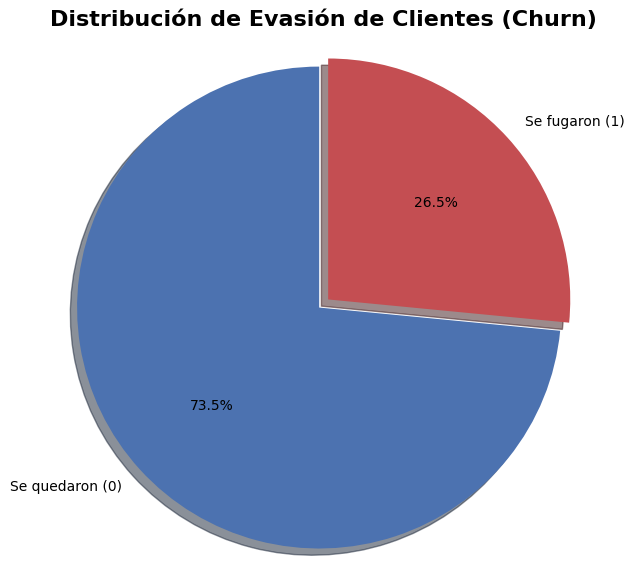

In [34]:
import matplotlib.pyplot as plt

# 1. Obtenemos los conteos
fuga_conteos = data_limpia['Fuga'].value_counts()

# 2. Configuramos el tamaño y colores
plt.figure(figsize=(7, 7))
colores = ['#4C72B0', '#C44E52']
etiquetas = ['Se quedaron (0)', 'Se fugaron (1)']

# 3. Creamos el gráfica
plt.pie(fuga_conteos, labels=etiquetas, autopct='%1.1f%%', startangle=90,
        colors=colores, explode=(0, 0.05), shadow=True)

# 4. Título y ajustes
plt.title('Distribución de Evasión de Clientes (Churn)', fontsize=16, fontweight='bold')
plt.axis('equal')

# 5. Mostramos la obra de arte
plt.show()

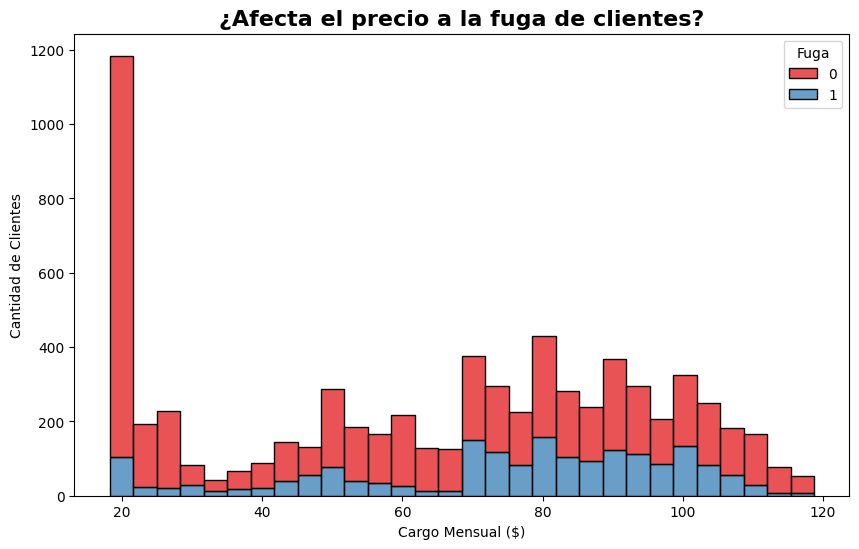

In [35]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Ajustamos el tamaño del lienzo
plt.figure(figsize=(10, 6))

# 2. Creamos un histograma.
# x = la variable que queremos medir (dinero)
# hue = la variable que separará los colores (si se fugó o no)
sns.histplot(data=data_limpia, x='Cargo_Mensual', hue='Fuga', multiple="stack", palette="Set1", bins=30)

# 3. Títulos y etiquetas para que se vea profesional
plt.title('¿Afecta el precio a la fuga de clientes?', fontsize=16, fontweight='bold')
plt.xlabel('Cargo Mensual ($)')
plt.ylabel('Cantidad de Clientes')

# 4. Mostrar gráfico
plt.show()

/tmp/ipykernel_532/2052749705.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data_limpia, x='Fuga', y='Meses_Antiguedad', palette='Set2')


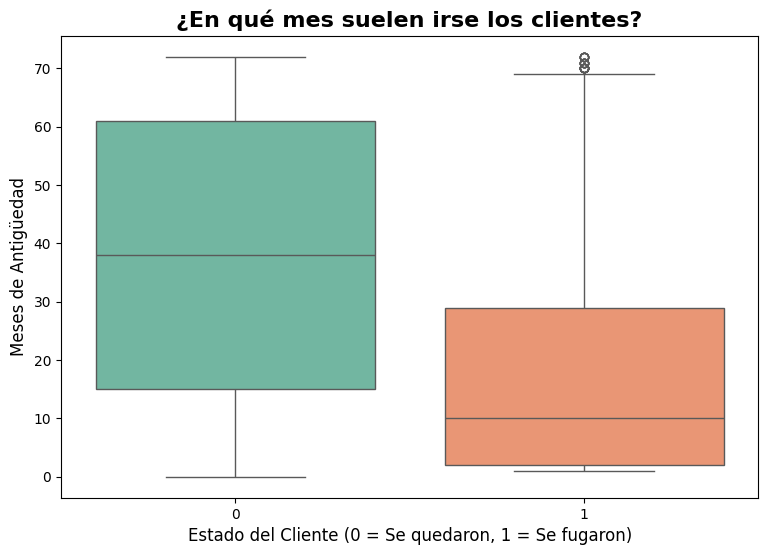

In [36]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Ajustamos el tamaño del lienzo
plt.figure(figsize=(9, 6))

# 2. Creamos el Gráfico de Cajas (Boxplot)
# En el eje X ponemos la Fuga (0 o 1) y en el eje Y los meses que llevan en la empresa
sns.boxplot(data=data_limpia, x='Fuga', y='Meses_Antiguedad', palette='Set2')

# 3. Títulos y etiquetas para que sea fácil de leer
plt.title('¿En qué mes suelen irse los clientes?', fontsize=16, fontweight='bold')
plt.xlabel('Estado del Cliente (0 = Se quedaron, 1 = Se fugaron)', fontsize=12)
plt.ylabel('Meses de Antigüedad', fontsize=12)

# 4. Mostramos el gráfico
plt.show()

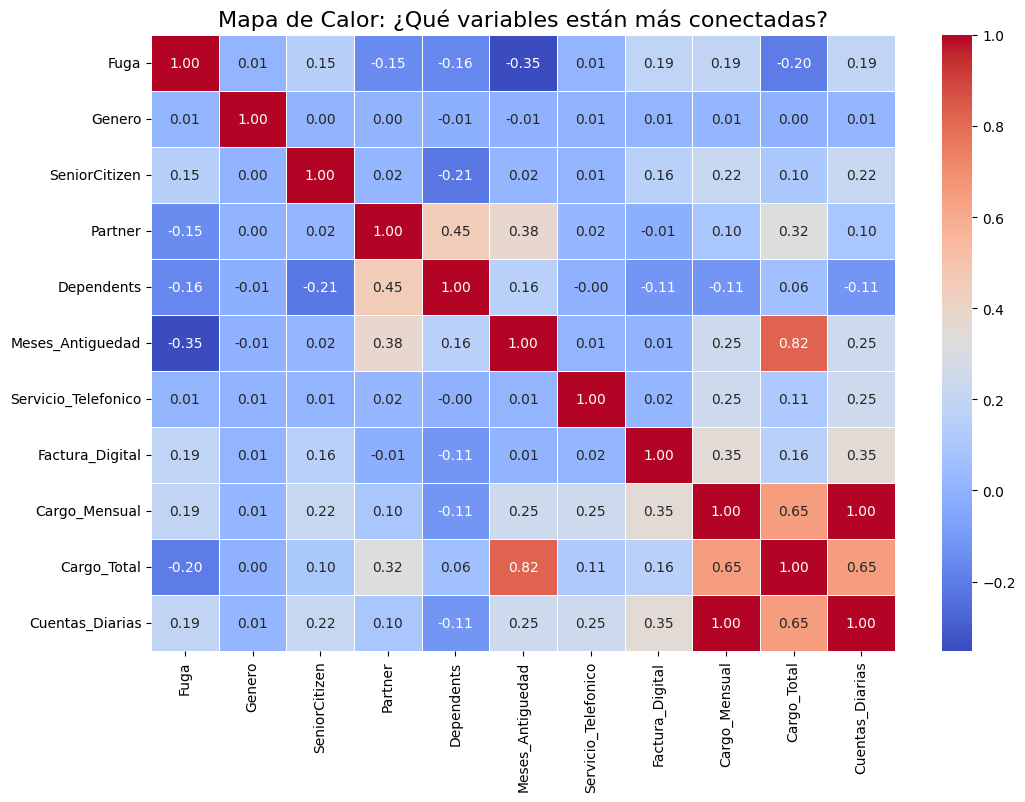

In [37]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Calculamos la correlación (solo de números)
corr = data_limpia.corr(numeric_only=True)

# 2. Configuramos el lienzo
plt.figure(figsize=(12, 8))

# 3. Creamos el Heatmap
# annot=True pone los números dentro de los cuadritos
# cmap='coolwarm' pone azul para lo negativo y rojo para lo positivo
sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm', linewidths=0.5)

# 4. Título
plt.title('Mapa de Calor: ¿Qué variables están más conectadas?', fontsize=16)

plt.show()

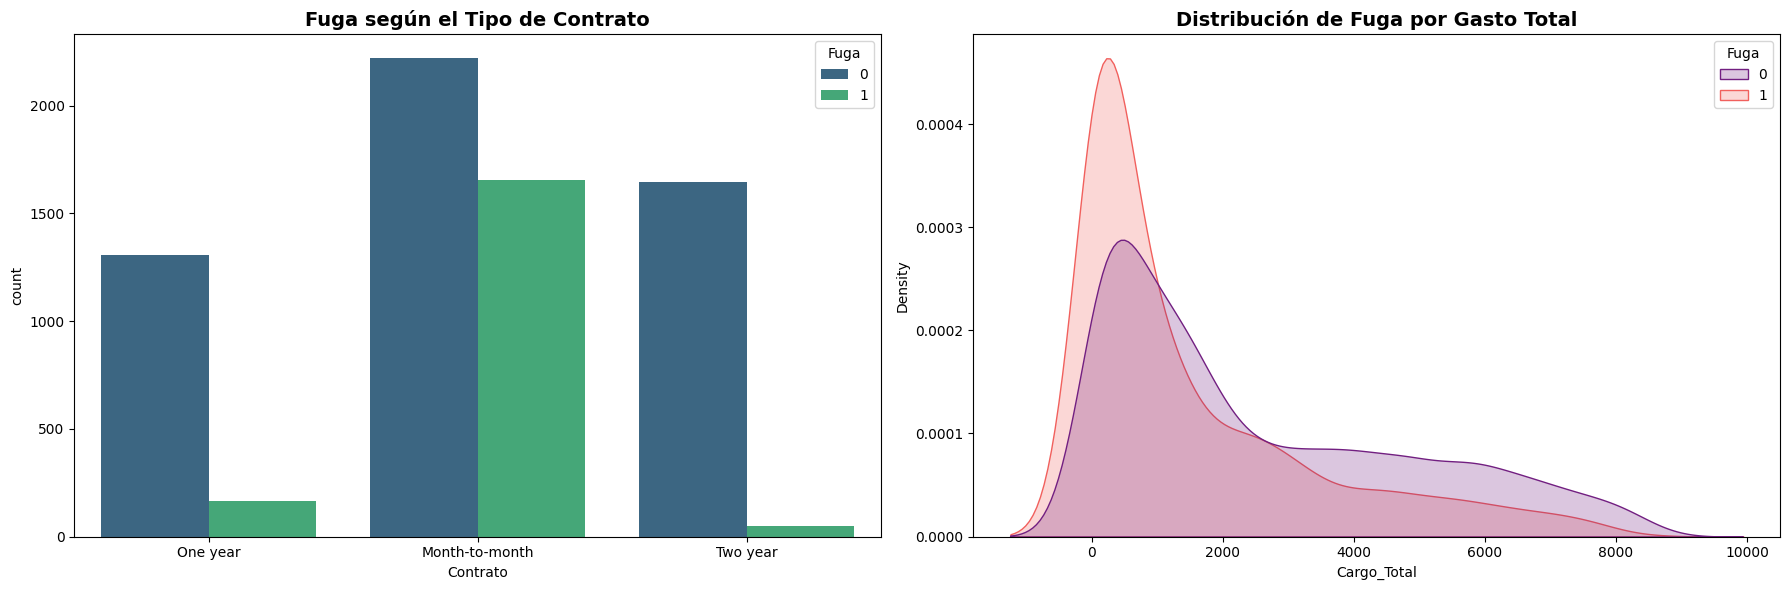

In [38]:
import seaborn as sns
import matplotlib.pyplot as plt

# Creamos un lienzo con dos gráficos lado a lado
fig, ax = plt.subplots(1, 2, figsize=(18, 6))

# 1. PARA LA TARJETA CATEGÓRICA: El impacto del contrato
#
sns.countplot(data=data_limpia, x='Contrato', hue='Fuga', palette='viridis', ax=ax[0])
ax[0].set_title('Fuga según el Tipo de Contrato', fontsize=14, fontweight='bold')

# 2. PARA LA TARJETA NUMÉRICA: El impacto del Cargo Total
#
sns.kdeplot(data=data_limpia, x='Cargo_Total', hue='Fuga', fill=True, common_norm=False, palette='magma', ax=ax[1])
ax[1].set_title('Distribución de Fuga por Gasto Total', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

1. ¿Que esta pasando? (Introduccion)
El problema principal de la empresa es que se nos esta llendo mucha gente. Tenemos una tasa de "Churn" (fuga) del 26.5%. Basicamente, de cada 10 clientes que entran, casi 3 se van. El objetivo aca es entender por que pasa esto.

2. Limpieza y orden de los datos
Para que el analisis sea real, primero tuvimos que arreglar el desorden:

Quitamos 224 clientes que tenian la celda de Fuga bacia porque no servian para el calculo.

Cambiamos los "Yes" y "No" por 1 y 0 para poder hacer graficos y cuentas matematicas.

Pasamos los nombres de las columnas al español para que cualquiera pueda leer la tabla sin problemas.

3. ¿Que descubrimos? (Analisis EDA)
Despues de ver varios graficos, bimos patrones muy claros:

El Precio: Los que pagan facturas de mas de $70 dolares son los que mas se fugan. Los planes baratos son mucho mas estables.

El Tiempo: La "zona de peligro" es el primer año. La mayoria se va antes de los 10 meses. Si pasan los 2 años, ya se quedan.

Contratos: Los que tienen contrato "Mes a mes" se ban muchisimo mas que los que firman por 1 o 2 años.

4. Conclusiones e Insights
El resumen es que la fuga no es al azar. Los clientes se van si sienten que el servicio es caro y si no tienen un compromiso a largo plazo. El primer año es clave para retenerlos.

5. Recomendaciones (¿Que hacemos ahora?)
Ganchos de retencion: Dar promos o descuentos a los clientes que llevan menos de un año para que no se vyan tan rapido.

Empujar contratos largos: Ofrecer algun beneficio si el cliente cambia su contrato de "mes a mes" a uno anual.

Foco en el segmento caro: Revisar que les estamos dando a los que pagan mas de $70, por que ahi es donde perdemos mas plata.

In [39]:
data_limpia.to_csv('TelecomX_tratado.csv', index=False, encoding='utf-8')

In [45]:
datax = pd.read_csv('/content/TelecomX_tratado.csv')

In [ ]:
datax.drop(columns['ID_Cliente'])

In [76]:
datax.shape

(7043, 21)

In [77]:
datax.head()

,Fuga,Genero,SeniorCitizen,Partner,Dependents,Meses_Antiguedad,Servicio_Telefonico,Multiples_Lineas,Servicio_Internet,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contrato,Factura_Digital,Metodo_Pago,Cargo_Mensual,Cargo_Total,Cuentas_Diarias
0,0,1,0,1,1,9,1,0,DSL,0,...,0,1,1,0,One year,1,Mailed check,65.6,593.30,2.19
1,0,0,0,0,0,9,1,1,DSL,0,...,0,0,0,1,Month-to-month,0,Mailed check,59.9,542.40,2.00
2,1,0,0,0,0,4,1,0,Fiber optic,0,...,1,0,0,0,Month-to-month,1,Electronic check,73.9,280.85,2.46
3,1,0,1,1,0,13,1,0,Fiber optic,0,...,1,0,1,1,Month-to-month,1,Electronic check,98.0,1237.85,3.27
4,1,1,1,1,0,3,1,0,Fiber optic,0,...,0,1,1,0,Month-to-month,1,Mailed check,83.9,267.40,2.80


In [80]:
# 1. Identificamos las columnas categóricas (texto)
columnas_categoricas = DataXCOM.select_dtypes(include=['object', 'category']).columns

In [81]:
# 2. Aplicamos get_dummies
# drop_first=True ayuda a evitar la multicolinealidad eliminando una columna redundante
DataXCOM_encoded = pd.get_dummies(DataXCOM, columns=columnas_categoricas, drop_first=True)

In [82]:
# 3. Mostramos el resultado
print(f'Nuevas dimensiones: {DataXCOM_encoded.shape}')
display(DataXCOM_encoded.head())

Nuevas dimensiones: (7043, 32)


,Fuga,Genero,SeniorCitizen,Partner,Dependents,Meses_Antiguedad,Servicio_Telefonico,Factura_Digital,Cargo_Mensual,Cargo_Total,...,TechSupport_No internet service,StreamingTV_1,StreamingTV_No internet service,StreamingMovies_1,StreamingMovies_No internet service,Contrato_One year,Contrato_Two year,Metodo_Pago_Credit card (automatic),Metodo_Pago_Electronic check,Metodo_Pago_Mailed check
0,0,1,0,1,1,9,1,1,65.6,593.30,...,False,True,False,False,False,True,False,False,False,True
1,0,0,0,0,0,9,1,0,59.9,542.40,...,False,False,False,True,False,False,False,False,False,True
2,1,0,0,0,0,4,1,1,73.9,280.85,...,False,False,False,False,False,False,False,False,True,False
3,1,0,1,1,0,13,1,1,98.0,1237.85,...,False,True,False,True,False,False,False,False,True,False
4,1,1,1,1,0,3,1,1,83.9,267.40,...,False,True,False,False,False,False,False,False,False,True


In [84]:
conteo_fuga = DataXCOM_encoded['Fuga'].value_counts()
proporcion_fuga = DataXCOM_encoded['Fuga'].value_counts(normalize=True) * 100

print('Distribución de Clientes (Fuga):')
print(conteo_fuga)
print('Proporción porcentual:')
print(proporcion_fuga)

if proporcion_fuga[1] < 40:
    print('Alerta: Existe un desbalance de clases. La minoría (Fuga=1) representa solo el ' + str(round(proporcion_fuga[1], 2)) + '%.')
else:
    print('Las clases están relativamente balanceadas.')

Distribución de Clientes (Fuga):
Fuga
0    5174
1    1869
Name: count, dtype: int64
Proporción porcentual:
Fuga
0    73.463013
1    26.536987
Name: proportion, dtype: float64
Alerta: Existe un desbalance de clases. La minoría (Fuga=1) representa solo el 26.54%.


In [86]:
from imblearn.over_sampling import SMOTE
from collections import Counter

# 1. Separamos nuestras variables (X) de lo que queremos predecir (y)
X = DataXCOM_encoded.drop(columns=['Fuga'])
y = DataXCOM_encoded['Fuga']

# 2. Inicializamos SMOTE
sm = SMOTE(random_state=42)

# 3. Aplicamos el re-muestreo
X_res, y_res = sm.fit_resample(X, y)

# 4. Verificamos el nuevo balance
print(f'Distribución original: {Counter(y)}')
print(f'Nueva distribución: {Counter(y_res)}')

# Ahora X_res y y_res están perfectamente balanceados para entrenar un modelo.

Distribución original: Counter({0: 5174, 1: 1869})
Nueva distribución: Counter({0: 5174, 1: 5174})


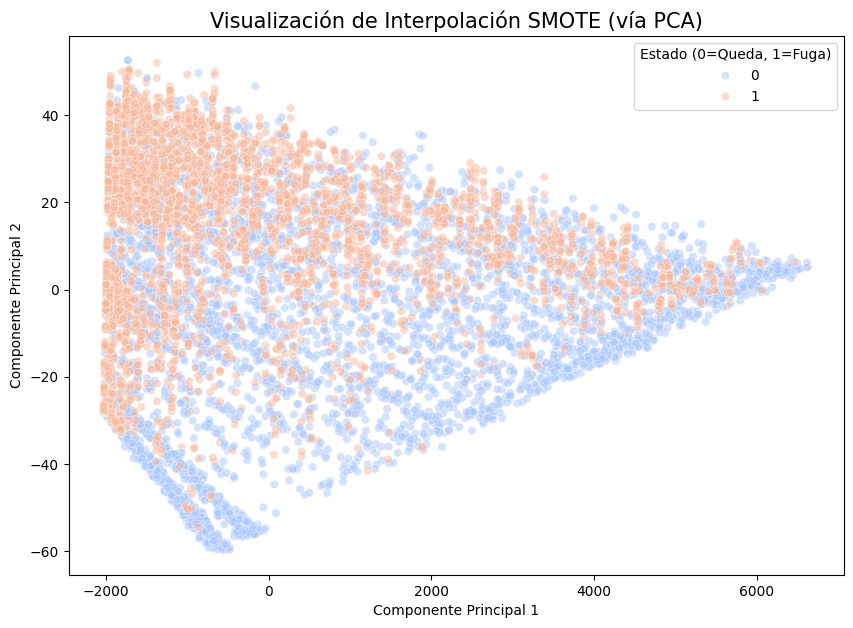

In [88]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 1. Reducimos las dimensiones de 32 a 2 para poder graficar
pca = PCA(n_components=2)
X_vis = pca.fit_transform(X_res)

# 2. Creamos un DataFrame para graficar
df_vis = pd.DataFrame(X_vis, columns=['PC1', 'PC2'])
df_vis['Fuga'] = y_res

# 3. Graficamos
plt.figure(figsize=(10, 7))
sns.scatterplot(data=df_vis, x='PC1', y='PC2', hue='Fuga', alpha=0.5, palette='coolwarm')

plt.title('Visualización de Interpolación SMOTE (vía PCA)', fontsize=15)
plt.xlabel('Componente Principal 1')
plt.ylabel('Componente Principal 2')
plt.legend(title='Estado (0=Queda, 1=Fuga)')
plt.show()

In [89]:
from sklearn.preprocessing import StandardScaler
import pandas as pd

# 1. Inicializamos el escalador
scaler = StandardScaler()

# 2. Ajustamos y transformamos las variables independientes (X_res)
# Conservamos los nombres de las columnas para mantener la legibilidad
X_scaled = pd.DataFrame(scaler.fit_transform(X_res), columns=X_res.columns)

# 3. Verificamos el resultado
print('Media aproximada (debe ser 0):', round(X_scaled.iloc[:, 0].mean(), 2))
print('Desviación estándar (debe ser 1):', X_scaled.iloc[:, 0].std())
display(X_scaled.head())

Media aproximada (debe ser 0): -0.0
Desviación estándar (debe ser 1): 1.0000483220179437


,Genero,SeniorCitizen,Partner,Dependents,Meses_Antiguedad,Servicio_Telefonico,Factura_Digital,Cargo_Mensual,Cargo_Total,Cuentas_Diarias,...,TechSupport_No internet service,StreamingTV_1,StreamingTV_No internet service,StreamingMovies_1,StreamingMovies_No internet service,Contrato_One year,Contrato_Two year,Metodo_Pago_Credit card (automatic),Metodo_Pago_Electronic check,Metodo_Pago_Mailed check
0,1.167286,-0.395876,1.280545,1.896056,-0.777767,0.33818,0.821734,-0.084700,-0.665769,-0.081214,...,-0.449908,1.114128,-0.449908,-0.897914,-0.449908,2.046208,-0.465199,-0.527411,-0.961320,1.796420
1,-0.856688,-0.395876,-0.780917,-0.527411,-0.777767,0.33818,-1.216939,-0.283177,-0.689046,-0.279670,...,-0.449908,-0.897563,-0.449908,1.113693,-0.449908,-0.488709,-0.465199,-0.527411,-0.961320,1.796420
2,-0.856688,-0.395876,-0.780917,-0.527411,-0.986220,0.33818,0.821734,0.204310,-0.808654,0.200801,...,-0.449908,-0.897563,-0.449908,-0.897914,-0.449908,-0.488709,-0.465199,-0.527411,1.040237,-0.556663
3,-0.856688,2.526041,1.280545,-0.527411,-0.611005,0.33818,0.821734,1.043485,-0.371012,1.046848,...,-0.449908,1.114128,-0.449908,1.113693,-0.449908,-0.488709,-0.465199,-0.527411,1.040237,-0.556663
4,1.167286,2.526041,1.280545,-0.527411,-1.027911,0.33818,0.821734,0.552516,-0.814805,0.555932,...,-0.449908,1.114128,-0.449908,-0.897914,-0.449908,-0.488709,-0.465199,-0.527411,-0.961320,1.796420


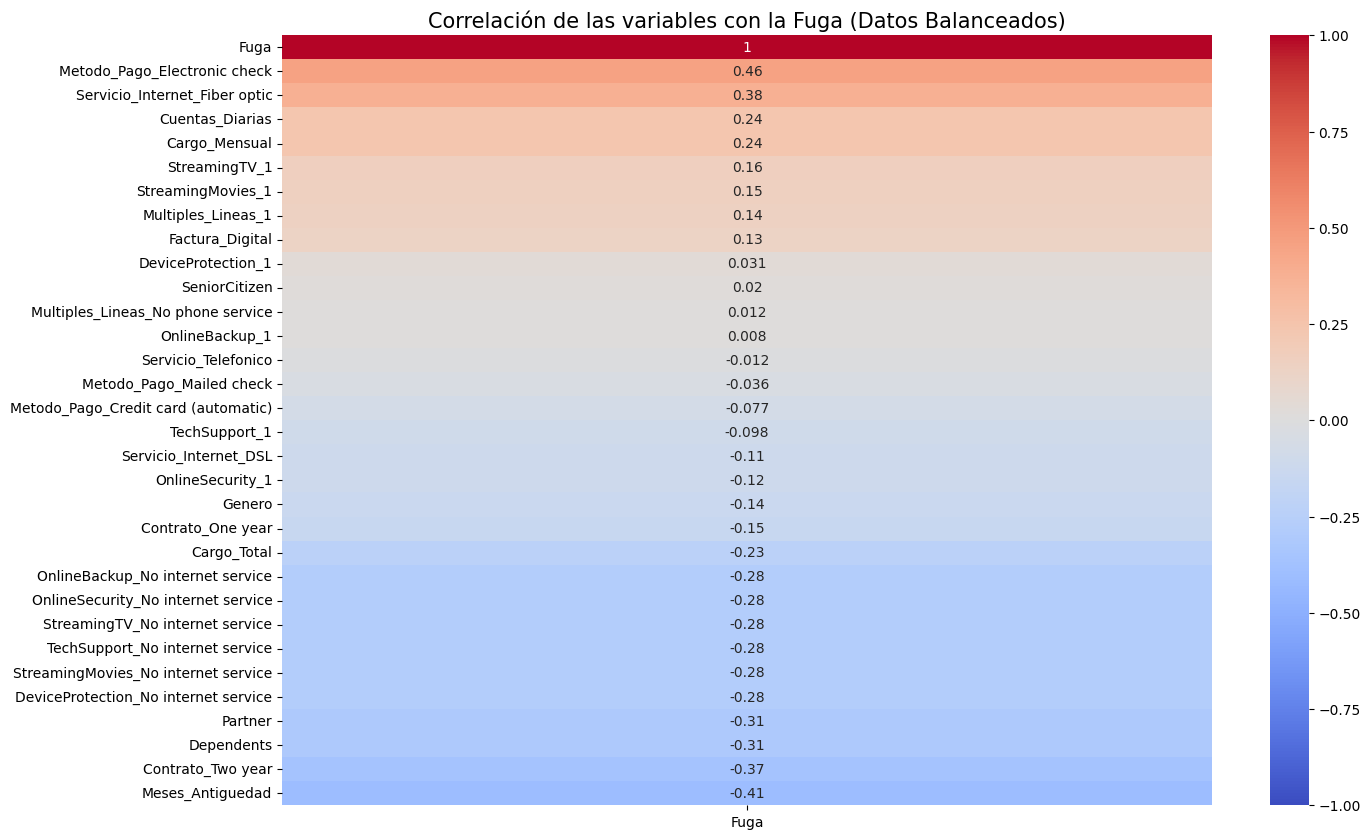

In [91]:
import seaborn as sns
import matplotlib.pyplot as plt

#Combinamos X_scaled con y_res para calcular la correlación completa
df_full_res = X_scaled.copy()
df_full_res['Fuga'] = y_res.values

#Calculamos la matriz de correlación
corr_matrix = df_full_res.corr()

#Graficamos el Heatmap
plt.figure(figsize=(15, 10))
sns.heatmap(corr_matrix[['Fuga']].sort_values(by='Fuga', ascending=False),
            annot=True, cmap='coolwarm', vmin=-1, vmax=1)

plt.title('Correlación de las variables con la Fuga (Datos Balanceados)', fontsize=15)
plt.show()

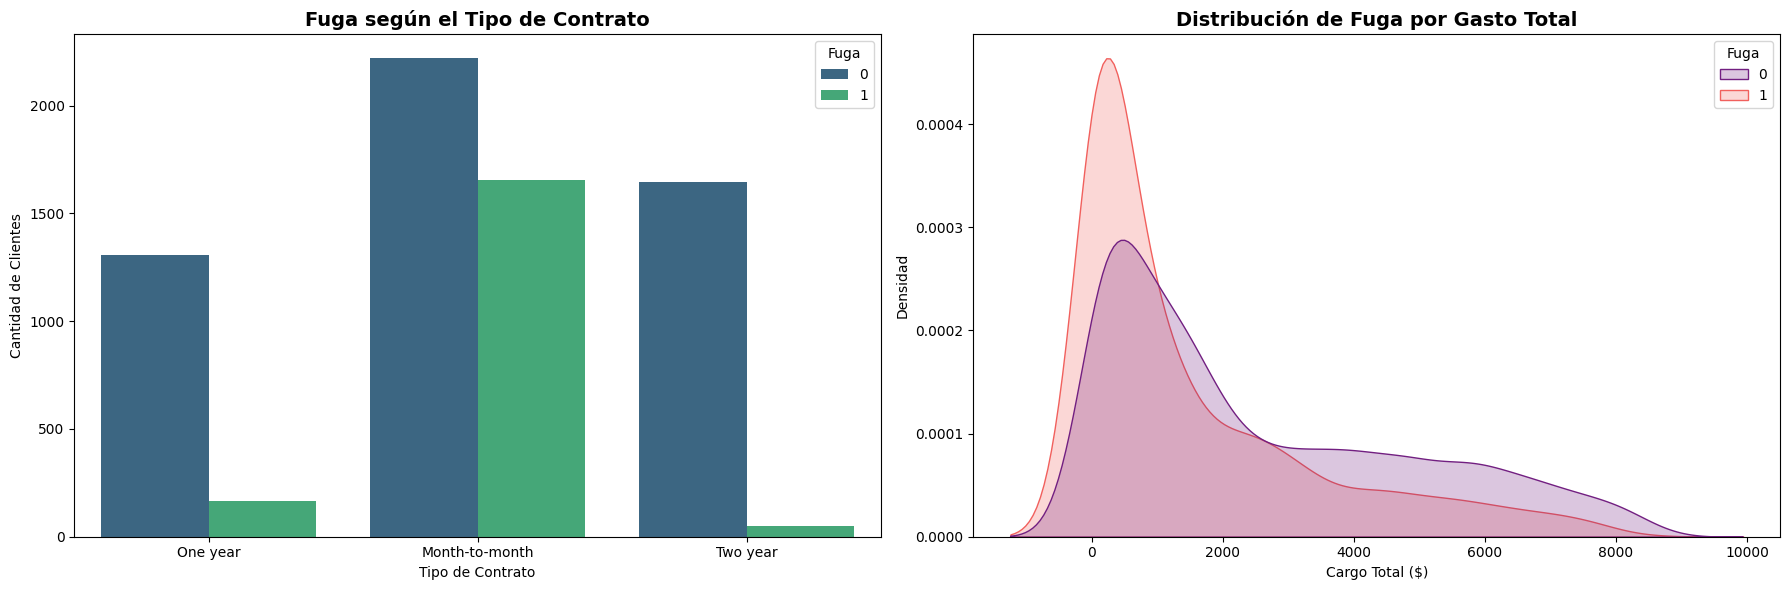

In [99]:
import seaborn as sns
import matplotlib.pyplot as plt

# Creamos un lienzo con dos gráficos lado a lado
fig, ax = plt.subplots(1, 2, figsize=(18, 6))

# IMPACTO DEL CONTRATO (Usamos DataXCOM original para etiquetas legibles)
sns.countplot(data=DataXCOM, x='Contrato', hue='Fuga', palette='viridis', ax=ax[0])
ax[0].set_title('Fuga según el Tipo de Contrato', fontsize=14, fontweight='bold')
ax[0].set_xlabel('Tipo de Contrato')
ax[0].set_ylabel('Cantidad de Clientes')

# 2. IMPACTO DEL GASTO TOTAL
sns.kdeplot(data=DataXCOM, x='Cargo_Total', hue='Fuga', fill=True, common_norm=False, palette='magma', ax=ax[1])
ax[1].set_title('Distribución de Fuga por Gasto Total', fontsize=14, fontweight='bold')
ax[1].set_xlabel('Cargo Total ($)')
ax[1].set_ylabel('Densidad')

plt.tight_layout()
plt.show()

In [101]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_res, test_size=0.20, random_state=42, stratify=y_res
)

print(f'Muestras de entrenamiento: {X_train.shape[0]}')
print(f'Muestras de prueba: {X_test.shape[0]}')
print('Distribución de clases en entrenamiento:\n', y_train.value_counts(normalize=True))

Muestras de entrenamiento: 8278
Muestras de prueba: 2070
Distribución de clases en entrenamiento:
 Fuga
1    0.5
0    0.5
Name: proportion, dtype: float64


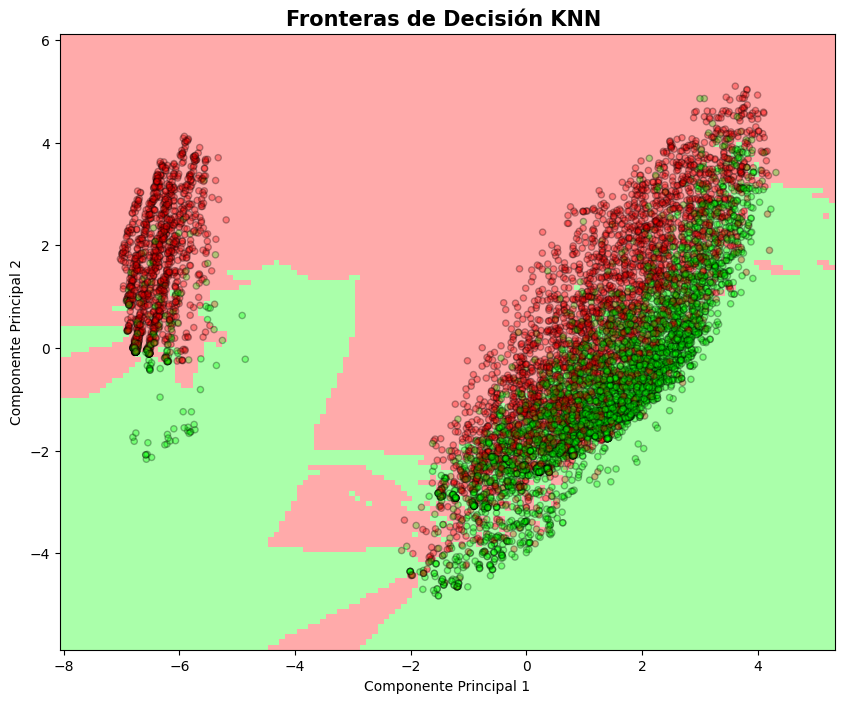

In [116]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from sklearn.decomposition import PCA
from sklearn.neighbors import KNeighborsClassifier

# 1. Reducimos a 2 dimensiones para visualizar el plano
pca_vis = PCA(n_components=2)
X_train_pca = pca_vis.fit_transform(X_train)

# 2. Entrenamos el KNN con los datos reducidos
knn_vis = KNeighborsClassifier(n_neighbors=5)
knn_vis.fit(X_train_pca, y_train)

# 3. Malla para las fronteras
h = .1
x_min, x_max = X_train_pca[:, 0].min() - 1, X_train_pca[:, 0].max() + 1
y_min, y_max = X_train_pca[:, 1].min() - 1, X_train_pca[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))

# 4. Predicciones en la malla
Z = knn_vis.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# 5. Gráfico
plt.figure(figsize=(10, 8))
cmap_light = ListedColormap(['#FFAAAA', '#AAFFAA'])
cmap_bold = ListedColormap(['#FF0000', '#00FF00'])

plt.pcolormesh(xx, yy, Z, cmap=cmap_light, shading='auto')
plt.scatter(X_train_pca[:, 0], X_train_pca[:, 1], c=y_train, cmap=cmap_bold, edgecolor='k', s=20, alpha=0.3)

plt.title("Fronteras de Decisión KNN ", fontsize=15, fontweight='bold')
plt.xlabel("Componente Principal 1")
plt.ylabel("Componente Principal 2")
plt.show()

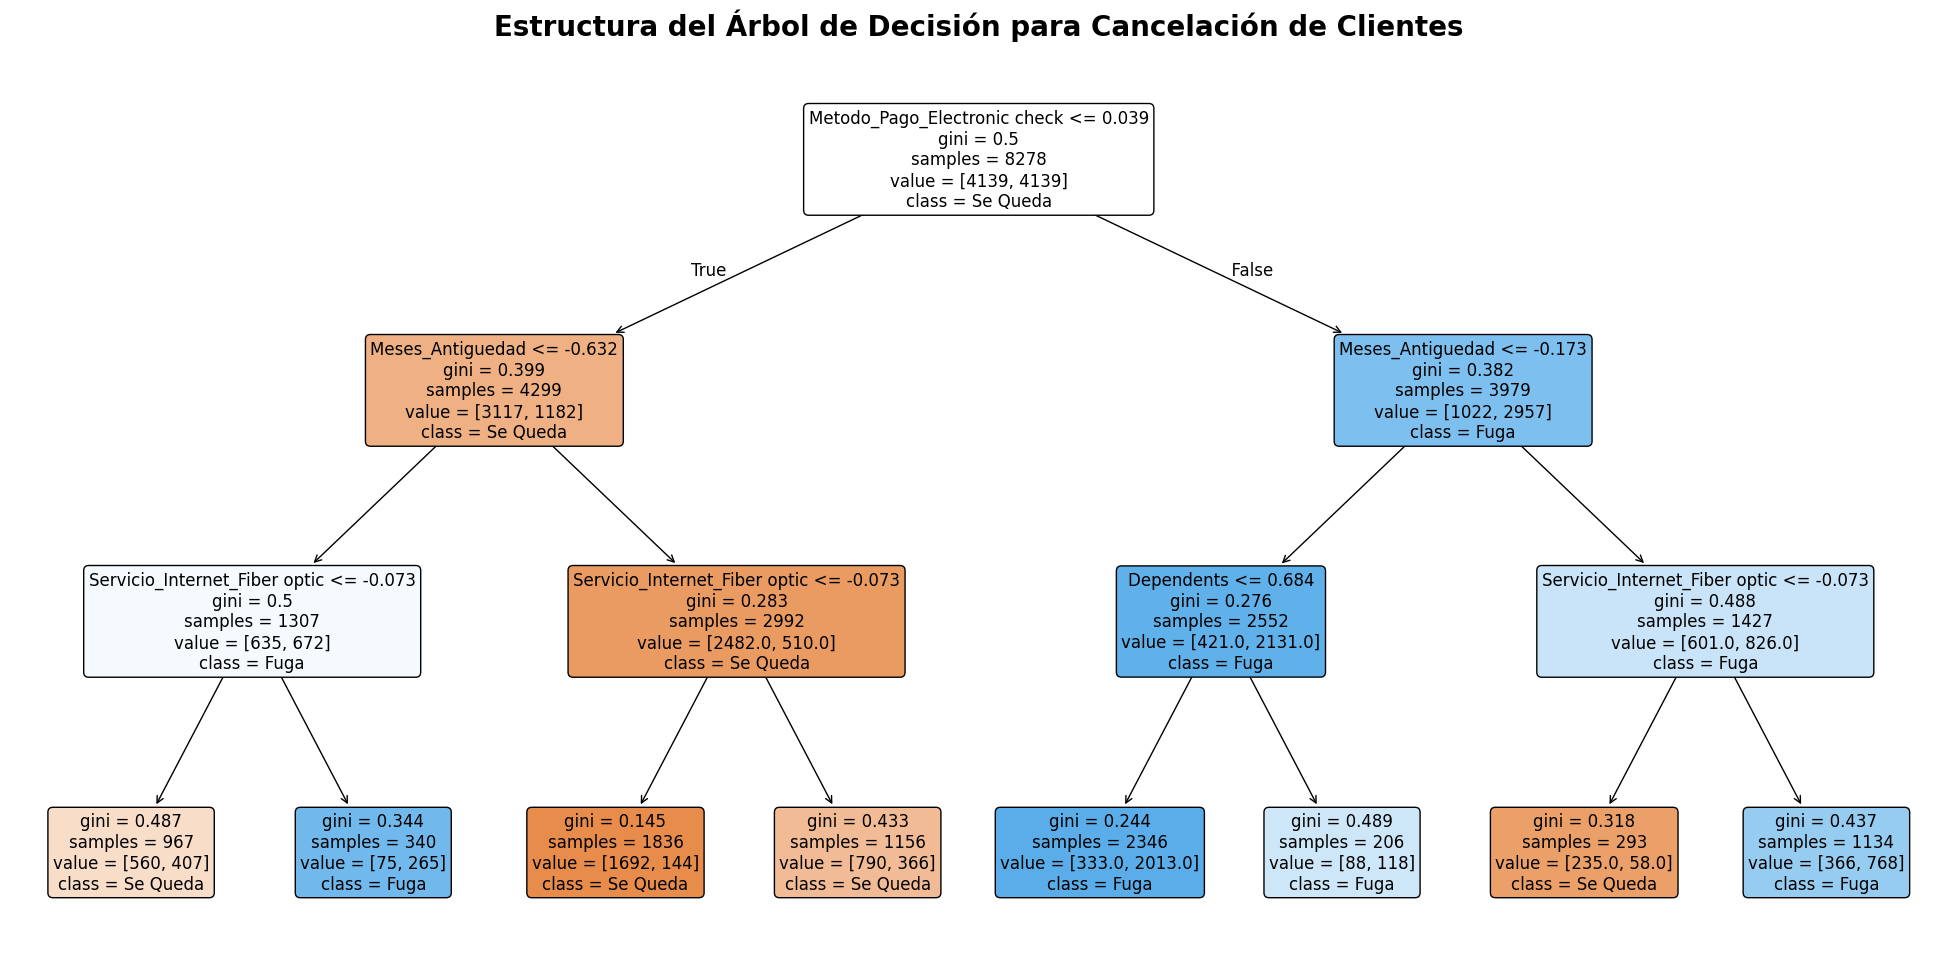

In [118]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

# 1. Entrenamos un árbol con profundidad limitada para que sea legible visualmente
dt_model_plot = DecisionTreeClassifier(max_depth=3, random_state=42)
dt_model_plot.fit(X_train, y_train)

# 2. Configuramos el lienzo
plt.figure(figsize=(25, 12))

# 3. Dibujamos el árbol
plot_tree(dt_model_plot,
          feature_names=X_train.columns,
          class_names=['Se Queda', 'Fuga'],
          filled=True,
          rounded=True,
          fontsize=12)

plt.title("Estructura del Árbol de Decisión para Cancelación de Clientes", fontsize=20, fontweight='bold')
plt.show()

In [123]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix

knn_model = KNeighborsClassifier(n_neighbors=5)


knn_model.fit(X_train, y_train)

y_pred_knn = knn_model.predict(X_test)

print('---  KNN (K=5) ---')
print(classification_report(y_test, y_pred_knn))

print('\n--- MATRIX DE CONFUSION ---')
print(confusion_matrix(y_test, y_pred_knn))

---  KNN (K=5) ---
              precision    recall  f1-score   support

           0       0.83      0.75      0.78      1035
           1       0.77      0.84      0.80      1035

    accuracy                           0.79      2070
   macro avg       0.80      0.79      0.79      2070
weighted avg       0.80      0.79      0.79      2070


--- MATRIX DE CONFUSION ---
[[774 261]
 [164 871]]


In [124]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix

dt_model = DecisionTreeClassifier(random_state=42)

dt_model.fit(X_train, y_train)

y_pred_dt = dt_model.predict(X_test)

print('--- ARBOL DE DECISION ---')
print(classification_report(y_test, y_pred_dt))

print('\n--- MATRIX DE CONFUSION ---')
print(confusion_matrix(y_test, y_pred_dt))

--- ARBOL DE DECISION ---
              precision    recall  f1-score   support

           0       0.80      0.78      0.79      1035
           1       0.79      0.80      0.79      1035

    accuracy                           0.79      2070
   macro avg       0.79      0.79      0.79      2070
weighted avg       0.79      0.79      0.79      2070


--- MATRIX DE CONFUSION ---
[[810 225]
 [208 827]]


***📋 Interpretación y Conclusiones***



Hallazgos clave del análisis de datos

En términos generales, ambos modelos tuvieron un desempeño bastante similar, ya que los dos alcanzaron una precisión global del 79%. Sin embargo, cada uno destacó en aspectos distintos, lo que permite ver con mayor claridad sus fortalezas.

En el caso de KNN con K=5, este modelo resultó especialmente útil para detectar a los clientes que realmente podrían abandonar el servicio. Logró un recall de 0.84 en la clase de churn, lo que significa que identificó correctamente a 871 clientes con riesgo de fuga. Esto es valioso cuando lo más importante es no dejar pasar a quienes podrían irse. Aun así, este buen nivel de detección vino acompañado de 261 falsos positivos, es decir, algunos clientes fueron señalados como posibles desertores sin serlo realmente. Para los no churners, obtuvo una precisión de 0.83 y un recall de 0.75.

Por otro lado, el modelo de árbol de decisión también mostró un desempeño sólido, con la misma accuracy del 79%. En la detección de churners alcanzó un recall de 0.80, identificando correctamente a 827 clientes que sí abandonarían el servicio. Aunque detectó un poco menos churners que KNN, presentó un comportamiento más equilibrado entre ambas clases. De hecho, sus F1-scores fueron de 0.79 tanto para churners como para no churners, lo que indica una respuesta más estable y uniforme.

Al comparar ambos modelos, se puede decir que existe un compromiso claro entre sus resultados. KNN es más agresivo para “atrapar” churners, por lo que puede ser una mejor opción si la prioridad es identificar la mayor cantidad posible de clientes en riesgo. En cambio, el árbol de decisión fue un poco más preciso al reconocer a los no churners, reflejándose en 810 verdaderos negativos frente a 774 obtenidos por KNN. En otras palabras, el árbol de decisión ofreció un rendimiento más balanceado, mientras que KNN destacó por su mayor sensibilidad para detectar abandono.

### 📋 Informe de Retención: Factores Clave y Estrategia

**1. Factores Determinantes de Cancelación:**
*   **Contrato:** El factor más crítico. Los clientes con contrato *mes a mes* tienen la tasa de fuga más alta.
*   **Cargo Mensual:** Clientes con facturas superiores a $70 presentan mayor riesgo.
*   **Método de Pago:** El uso de *cheque electrónico* está fuertemente vinculado a la cancelación.
*   **Antigüedad:** Los primeros 12 meses representan la 'zona de peligro' para la deserción.

**2. Comparativa de Modelos:**
*   **KNN (K=5):** Es el mejor para la empresa (**Recall: 0.84**). Aunque genera más falsas alarmas, detecta a la mayoría de clientes en riesgo real.
*   **Árbol de Decisión:** Más equilibrado pero menos sensible para captar fugas críticas.

**3. Estrategias de Retención Propuestas:**
*   **Incentivo de Permanencia:** Ofrecer descuentos exclusivos para migrar a clientes de contratos 'mes a mes' a contratos anuales.
*   **Fidelización Temprana:** Implementar programas de beneficios durante el primer año para aumentar la antigüedad del cliente.
*   **Optimización de Pagos:** Promover el cambio de cheque electrónico a métodos automáticos (tarjeta/cuenta) mediante pequeñas bonificaciones.